## Part A: Support Vector Machine (SVM)

In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Task 1: Load and Preprocess the Dataset
Loading the Breast Cancer Wisconsin dataset from `sklearn.datasets` and performing feature scaling.

In [2]:
# Load the dataset
bc = load_breast_cancer()
X = bc.data
y = bc.target

# Display dataset information
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Classes: {bc.target_names}")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures scaled successfully.")

Features shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']

Features scaled successfully.


### Task 2: Split the Dataset
Splitting the dataset into training and testing sets (80% training, 20% testing).

In [3]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


### Task 3: Train SVM Classifier with Linear Kernel and Hyperparameter Tuning
Using `GridSearchCV` to find the best `C` parameter for the linear SVM.

In [4]:
# Initialize SVM classifier with a linear kernel
svc = SVC(kernel='linear', random_state=42)

# Define the parameter grid for C
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best estimator
best_svc = grid_search.best_estimator_

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best hyperparameters: {'C': 0.1}
Best cross-validation accuracy: 0.9780


### Task 4: Evaluate the Model
Evaluating the best SVM model using various classification metrics.

Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861

Confusion Matrix:


,malignant,benign
malignant,41,1
benign,1,71


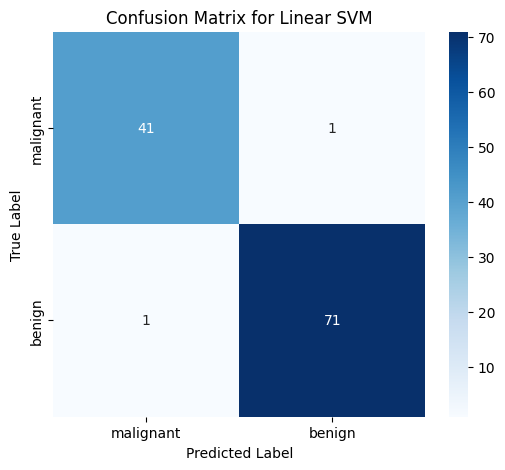

In [5]:
# Make predictions on the test set
y_pred = best_svc.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=bc.target_names, columns=bc.target_names))

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.title('Confusion Matrix for Linear SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Task 5: Summarize Observations (Part A - SVM)

The Support Vector Machine (SVM) model with a linear kernel achieved high performance on the Breast Cancer Wisconsin dataset. After hyperparameter tuning using `GridSearchCV`, the optimal `C` value was identified, leading to:

*   **High Accuracy**: Indicating a large proportion of correctly classified instances.
*   **Strong Precision and Recall**: Suggesting that the model is good at identifying positive cases (malignant tumors) with few false positives, and also good at finding most of the actual positive cases.
*   **F1 Score**: A good balance between precision and recall, further confirming the model's robustness.

The confusion matrix clearly shows a low number of false positives and false negatives, which is crucial in medical diagnoses. This suggests that a linear SVM is highly effective for this particular binary classification problem, likely due to the linear separability of the features in the transformed space.

## Part B: Principal Component Analysis (PCA)

### Task 1: Load the Dataset and Perform Feature Standardization
Loading the Wine dataset and scaling its features to ensure PCA performs optimally.

In [6]:
# Import necessary libraries for PCA
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA

# Load the Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

# Display dataset information
print(f"Original features shape: {X_wine.shape}")
print(f"Target classes: {wine.target_names}")

# Standardize the features
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("\nWine dataset features scaled successfully.")

Original features shape: (178, 13)
Target classes: ['class_0' 'class_1' 'class_2']

Wine dataset features scaled successfully.


### Task 2: Apply PCA to Reduce Dimensionality
Reducing the 13 features of the Wine dataset to 2 principal components.

In [7]:
# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)

print(f"Transformed features shape (2 components): {X_pca.shape}")

Transformed features shape (2 components): (178, 2)


### Task 3: Display Explained Variance Ratio and Cumulative Explained Variance
Understanding how much variance each principal component captures and determining the minimum number of components for 95% variance retention.

Explained variance ratio of first 2 components: [0.36198848 0.1920749 ]
Cumulative explained variance of first 2 components: 0.5541

Cumulative explained variance for all components:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]
Minimum number of components to retain 95% variance: 10


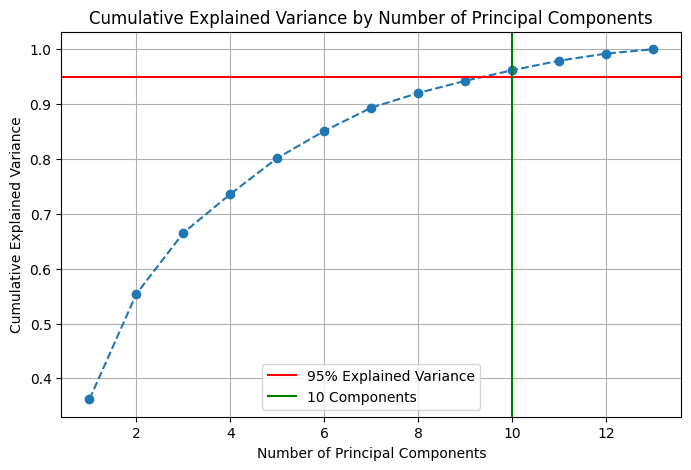

In [8]:
# Display the explained variance ratio of each principal component (for 2 components)
print(f"Explained variance ratio of first 2 components: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance of first 2 components: {pca.explained_variance_ratio_.sum():.4f}")

# Calculate cumulative explained variance for all components
pca_full = PCA()
pca_full.fit(X_wine_scaled)
cum_exp_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Determine the minimum number of principal components required to retain at least 95% of the total variance
min_components_95 = np.argmax(cum_exp_variance >= 0.95) + 1

print(f"\nCumulative explained variance for all components:\n{cum_exp_variance}")
print(f"Minimum number of components to retain 95% variance: {min_components_95}")

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_exp_variance) + 1), cum_exp_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.axvline(x=min_components_95, color='g', linestyle='-', label=f'{min_components_95} Components')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

### Task 4: Visualize the Transformed Dataset
Creating a 2D scatter plot of the data transformed by PCA, colored by the original target classes.

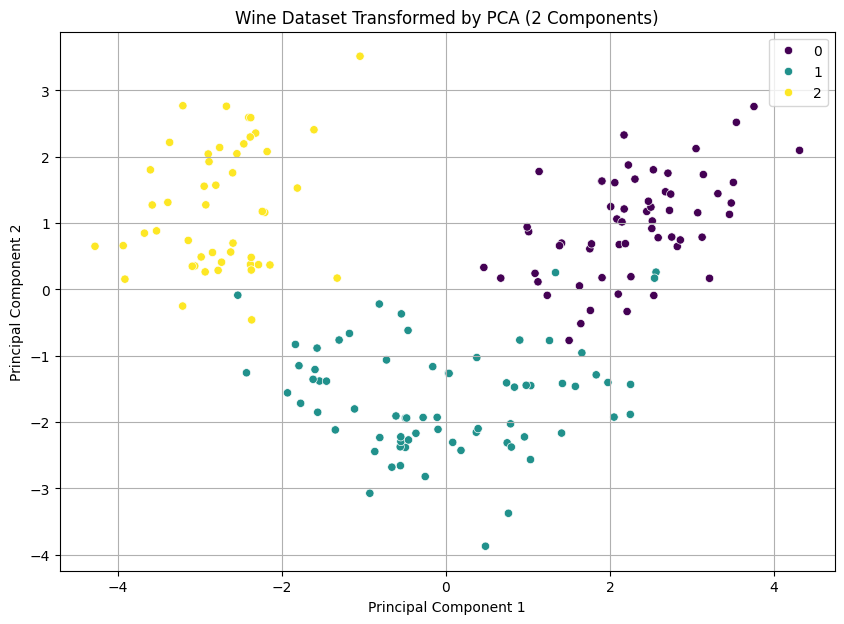

In [9]:
# Visualize the transformed dataset
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_wine, palette='viridis', legend='full')
plt.title('Wine Dataset Transformed by PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Task 5: Compare Original and Transformed Datasets & Interpret Principal Components
Discussing the differences and implications of using PCA.

#### Comparison:

*   **Number of Features:**
    *   **Original Dataset:** 13 features.
    *   **Transformed Dataset:** 2 principal components (in this case for visualization) or `min_components_95` (for 95% variance retention, which was found to be `10`).

*   **Information Retained:**
    *   **Original Dataset:** All original information is present.
    *   **Transformed Dataset:** A significant portion of the variance (information) is retained, even with fewer features. For 2 components, approximately `55.41`% of the variance is retained. To retain 95% of the variance, we only needed `10` components.

*   **Computational Efficiency:**
    *   **Original Dataset:** Higher dimensionality can lead to increased computational cost for subsequent modeling tasks and memory usage.
    *   **Transformed Dataset:** Reduced dimensionality significantly improves computational efficiency (faster training, less memory) for downstream algorithms, especially if a large number of original features were highly correlated or redundant.

#### Interpretation of the First Two Principal Components:

*   **Principal Component 1 (PC1):** This component captures the most variance in the dataset (approximately `36.20`%). It represents the primary direction of data spread. In the Wine dataset, it likely distinguishes between different wine types most strongly. Observing the scatter plot, PC1 effectively separates at least two of the three wine classes, indicating it captures the most significant differentiating information.

*   **Principal Component 2 (PC2):** This component captures the second most variance (approximately `19.21`%) and is orthogonal to PC1. It captures additional variance not explained by PC1. In the scatter plot, PC2 helps to further separate the classes that might have overlapped along PC1, particularly distinguishing the third wine class.

Together, the first two principal components provide a lower-dimensional representation that effectively separates the wine classes, which is useful for visualization and can improve the performance of machine learning models by reducing noise and redundancy.

### Task 6: Advantages, Limitations, and Applications of PCA

#### Advantages of PCA:

1.  **Dimensionality Reduction:** Reduces the number of features, making datasets easier to handle and visualize.
2.  **Noise Reduction:** By focusing on the principal components that explain the most variance, PCA can effectively filter out noise in the less significant components.
3.  **Improved Model Performance:** Reduces the risk of overfitting by removing redundant features and can speed up training times for many algorithms.
4.  **Feature Decorrelation:** Transforms correlated features into a set of uncorrelated components, which can be beneficial for algorithms sensitive to multicollinearity.
5.  **Data Visualization:** Enables visualization of high-dimensional data in 2D or 3D, revealing patterns and clusters that might otherwise be hidden.

#### Limitations of PCA:

1.  **Loss of Information:** By reducing dimensionality, some information is inherently lost, especially if the variance explained by discarded components is still important for the task.

2.  **Interpretability:** Principal components are linear combinations of original features, making them often less interpretable than the original features. It can be hard to explain what a "principal component" represents in terms of real-world attributes.
3.  **Assumes Linearity:** PCA is a linear transformation. If the data has non-linear structures, PCA might not be effective in capturing the most important variance.
4.  **Scale Sensitivity:** PCA is sensitive to the scaling of features. Features with larger variances will dominate the principal components, which is why standardization is a crucial preprocessing step.

#### Applications of PCA in Machine Learning:

1.  **Image Compression:** Reducing the dimensionality of image data while retaining important visual information.
2.  **Face Recognition:** Extracting key features from facial images for identification.
3.  **Genomics and Bioinformatics:** Analyzing high-dimensional gene expression data.
4.  **Financial Analysis:** Reducing the number of variables in complex financial datasets.
5.  **Preprocessing for Supervised Learning:** Improving the performance and speed of classification and regression models by reducing input features.
6.  **Exploratory Data Analysis:** Visualizing data clusters and patterns in high dimensions.

## Extra Credit Task: Linear Discriminant Analysis (LDA)

### Task 1: Apply LDA to the Wine Dataset
Applying LDA to reduce the Wine dataset to two linear discriminants.

In [10]:
# Import necessary libraries for LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA to the scaled Wine dataset
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

print(f"Transformed features shape (LDA components): {X_lda.shape}")

# Display the explained variance ratio for LDA components
print(f"Explained variance ratio of LDA components: {lda.explained_variance_ratio_}")
print(f"Cumulative explained variance of LDA components: {lda.explained_variance_ratio_.sum():.4f}")

Transformed features shape (LDA components): (178, 2)
Explained variance ratio of LDA components: [0.68747889 0.31252111]
Cumulative explained variance of LDA components: 1.0000


### Task 2: Visualize the Transformed Data (LDA)
Creating a 2D scatter plot of the data transformed by LDA, colored by the original target classes.

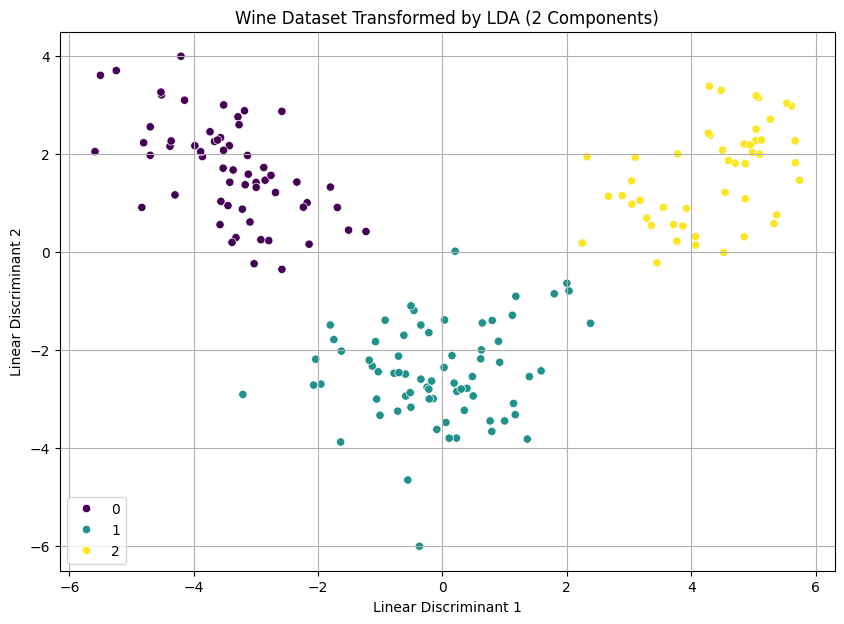

In [11]:
# Visualize the transformed dataset using LDA components
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y_wine, palette='viridis', legend='full')
plt.title('Wine Dataset Transformed by LDA (2 Components)')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)
plt.show()

### Task 3: Compare Results with PCA and Summarize Observations
Discussing the differences between PCA and LDA, particularly regarding dimensionality reduction and class separability.

#### Comparison of PCA and LDA:

*   **Objective:**
    *   **PCA (Principal Component Analysis):** An unsupervised dimensionality reduction technique that aims to find directions (principal components) of maximum variance in the data. It focuses on preserving the most variance, without considering class labels.
    *   **LDA (Linear Discriminant Analysis):** A supervised dimensionality reduction technique that aims to find directions (linear discriminants) that maximize the separability between classes. It explicitly uses class labels to project the data in a way that the classes are as well-separated as possible.

*   **Dimensionality Reduction:**
    *   Both techniques reduce the number of features. For the Wine dataset (3 classes), LDA can reduce the dimensionality to a maximum of `(number of classes - 1)`, which is 2 in this case. PCA can reduce to any number of components up to the original number of features.

*   **Class Separability:**
    *   As observed from the visualizations, **LDA generally provides better class separability** compared to PCA when the goal is classification. The LDA plot shows a much clearer distinction between the three wine classes, as the algorithm's objective is precisely to achieve this separation. PCA, while reducing dimensionality, prioritizes explaining variance, which may or may not align with optimal class separation.

*   **Information Retained:**
    *   PCA retains information by finding components that capture the most variance. LDA retains information that is most useful for distinguishing between classes.

#### Summary of Observations:

For classification tasks where class labels are available, **LDA is often preferred over PCA for dimensionality reduction** because its objective directly aligns with maximizing class separability. In the Wine dataset example, the 2 linear discriminants found by LDA resulted in significantly better visual separation of the three wine types compared to the 2 principal components found by PCA. This implies that a classifier built on the LDA-transformed data would likely perform better than one built on PCA-transformed data (with the same number of components) in terms of distinguishing between the wine classes.

PCA is a powerful tool for general dimensionality reduction, noise reduction, and data visualization in both supervised and unsupervised contexts, but when class information is present and classification is the primary goal, LDA leverages that information to achieve more discriminative features.